# 13. A custom objective

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

Every other fitting verb in this package -- `Distribution.fit()`, `fit_mle()`,
`model_bulletin17c()` and friends -- wraps a model the port already knows how to build.
Sometimes the model is yours: a custom rating curve, a regional regression, anything you can
write as a likelihood in a handful of lines. `optim_minimize()`/`optim_maximize()` expose the
same six ported Numerics optimizers those verbs use internally, over a plain Python function, so
a hand-written likelihood gets the same optimizers -- including the same seeded differential
evolution, whose PARAMETERS reproduce bit-exact across languages -- as the built-in models. It
has no upstream counterpart: the USACE-RMC Numerics-Python-Examples repository has no
general-purpose optimization notebook.

## What you'll learn

- Write a small negative log-likelihood by hand and hand it to `optim_minimize()`.
- Fit it two ways -- global (`"de"`, seeded) and local (`"bfgs"`, from a starting guess) -- and
  see the two agree.
- Confirm the seeded `"de"` run's PARAMETERS are bit-identical to the R twin's: the optimizer's
  candidate-generating random number stream lives in the shared C++ core, not in R or Python.
- `optim_maximize()`'s sign convention: it does not negate the objective's own value.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import corehydropy as ch

## A synthetic rating curve

A power-law stage-discharge relationship, $Q = a\,(h - h_0)^b$, is the classic hydraulic rating
curve -- discharge as a power of stage above some effective channel-control elevation $h_0$. This
is deliberately NOT the BaRatin model behind `rating_curve_analysis()` (that one fits a
matrix-of-controls addition-mode curve with its own log10-space likelihood); it is a small,
different model written from scratch to show what `optim_minimize()` is for.

Twenty-five stage readings and a synthetic "true" curve with multiplicative log-normal
measurement error -- the noise draw is seeded through the port, so it is bit-identical to the R
twin's.

First three discharges: 4.668426, 12.377813, 22.499345


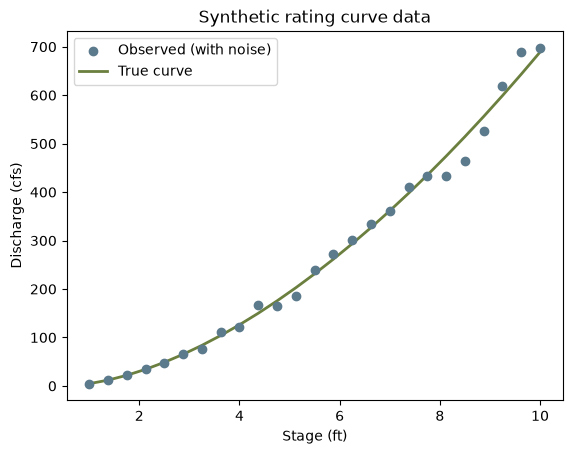

In [2]:
stage = np.linspace(1, 10, 25)
a_true, b_true, h0_true = 15.0, 1.7, 0.5
discharge_true = a_true * (stage - h0_true) ** b_true

noise = np.asarray(ch.Distribution("Normal", [0, 0.05]).random(25, seed=2024))
discharge = discharge_true * np.exp(noise)

print("First three discharges:", ", ".join(f"{v:.6f}" for v in discharge[:3]))
plt.scatter(stage, discharge, color="#5b7a8c", label="Observed (with noise)", zorder=3)
plt.plot(stage, discharge_true, color="#6b7f3f", linewidth=2, label="True curve")
plt.xlabel("Stage (ft)")
plt.ylabel("Discharge (cfs)")
plt.title("Synthetic rating curve data")
plt.legend()
plt.show()

## The likelihood

Four parameters: $a$, $b$, $h_0$, and the log-space error standard deviation $\sigma$. Assuming
independent log-normal errors, the negative log-likelihood is

$$
-\ell(a, b, h_0, \sigma) = \sum_{i=1}^{n} \left[
  \tfrac12 \log(2\pi\sigma^2) + \frac{\left(\log Q_i - \log\hat{Q}_i\right)^2}{2\sigma^2}
\right], \qquad \hat{Q}_i = a\,(h_i - h_0)^b
$$

`optim_minimize()` needs `lower`/`upper` bounds for every method, including `"de"`, which takes
no starting guess at all; `"bfgs"` additionally needs one (`initial`).

In [3]:
def nll(p):
    a, b, h0, sigma = p
    predicted = a * np.maximum(stage - h0, 1e-6) ** b
    resid = np.log(discharge) - np.log(predicted)
    return -np.sum(-0.5 * np.log(2 * np.pi * sigma**2) - resid**2 / (2 * sigma**2))

lower = [1, 0.5, 0, 0.001]
upper = [50, 4, 2, 1]

## Fit two ways

Differential evolution (`"de"`) is a global, population-based, stochastic method -- seeded here,
so it reproduces exactly on every run and, more importantly, its PARAMETERS reproduce exactly in
the R twin (see the reproduction check for the caveat on `value` and on BFGS). BFGS is a local,
gradient-based method that needs a starting guess; `control={"compute_hessian": False}` skips the
(here, unneeded) numerical Hessian both methods compute by default.

In [4]:
fit_de = ch.optim_minimize(nll, lower=lower, upper=upper, method="de", seed=2024,
                            control={"compute_hessian": False})
fit_bfgs = ch.optim_minimize(nll, lower=lower, upper=upper, initial=[10, 1, 0, 0.1],
                              method="bfgs", control={"compute_hessian": False})

print(fit_de)
print(fit_bfgs)

<OptimResult Success after 173 iterations (6960 evaluations)>
  value: -37.317232
  parameters: [15.050239  1.694614  0.495115  0.054387]
<OptimResult Success after 26 iterations (630 evaluations)>
  value: -37.317232
  parameters: [15.049867  1.694626  0.495104  0.054387]


Global and local agree to about four decimal places, and both land close to the true generating
parameters ($a=15$, $b=1.7$, $h_0=0.5$, $\sigma=0.05$) -- unsurprising with a clean,
well-identified likelihood and only mild noise, but worth checking rather than assuming.

In [5]:
comparison = {
    "True": [a_true, b_true, h0_true, 0.05],
    "DE": fit_de.parameters,
    "BFGS": fit_bfgs.parameters,
}
for name, params in comparison.items():
    print(f"{name:>5}:", np.round(params, 4))

 True: [15.    1.7   0.5   0.05]
   DE: [15.0502  1.6946  0.4951  0.0544]
 BFGS: [15.0499  1.6946  0.4951  0.0544]


## `optim_maximize()`'s sign convention

Maximizing the log-likelihood directly (the negation of `nll`) with the same seed lands on the
same parameters DE found minimizing `nll` -- and `optim_maximize()`'s reported `value` is the
objective's OWN value at the optimum, not negated, so it comes out as `-fit_de.value` rather than
`fit_de.value`.

In [6]:
def log_likelihood(p):
    return -nll(p)

fit_de_max = ch.optim_maximize(log_likelihood, lower=lower, upper=upper, method="de", seed=2024,
                                control={"compute_hessian": False})
print(f"optim_minimize(nll).value:            {fit_de.value:.6f}")
print(f"optim_maximize(log_likelihood).value: {fit_de_max.value:.6f}")
print("Same parameters:", np.allclose(fit_de.parameters, fit_de_max.parameters))

optim_minimize(nll).value:            -37.317232
optim_maximize(log_likelihood).value: 37.317232
Same parameters: True


## Plot: fitted curve

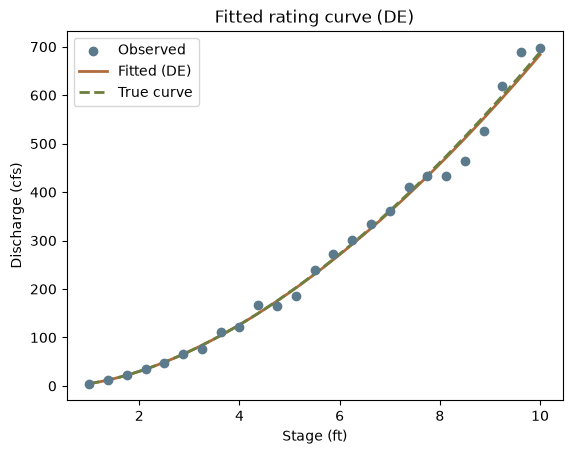

In [7]:
h_grid = np.linspace(stage.min(), stage.max(), 200)
a_hat, b_hat, h0_hat, _ = fit_de.parameters
fitted_curve = a_hat * np.maximum(h_grid - h0_hat, 0) ** b_hat

plt.scatter(stage, discharge, color="#5b7a8c", label="Observed", zorder=3)
plt.plot(h_grid, fitted_curve, color="#b06a3b", linewidth=2, label="Fitted (DE)")
plt.plot(stage, discharge_true, color="#6b7f3f", linewidth=2, linestyle="--", label="True curve")
plt.xlabel("Stage (ft)")
plt.ylabel("Discharge (cfs)")
plt.title("Fitted rating curve (DE)")
plt.legend()
plt.show()

## Key takeaways

1. `optim_minimize()`/`optim_maximize()` take any Python callable of a numeric parameter vector
   -- nothing about the model needs to be one the port already knows how to build.
2. A seeded `"de"` run's PARAMETERS are exactly reproducible, run to run and language to
   language: the PRNG lives in the shared C++ core, not in R's or Python's own random state. The
   reported objective VALUE only agrees to about 15 decimal digits, because it comes from
   re-evaluating each language's own likelihood code.
3. Global (`"de"`) and local (`"bfgs"`) methods are worth cross-checking against each other on
   the same objective, not just trusted individually.
4. `optim_maximize()`'s `value` is the objective's own value at the optimum -- never negated --
   so maximizing `log_likelihood` reports the log-likelihood itself, not its negation.

## Reproduction check

No upstream literals exist for this example (it has no upstream counterpart), so every value
below is an internal-consistency or cross-language check. One honest floating-point note, in the
same spirit as example 09's Box-Cox lambda: `discharge` and DE's `parameters` are bit-identical
across languages, because they never leave the shared, seeded C++ core (the synthetic-noise draw
and DE's own candidate-generation stream). `fit_de.value`, by contrast, comes from re-evaluating
THIS PAGE'S OWN likelihood -- a hand-written formula here, R's `dnorm(..., log = TRUE)` in the R
twin -- at that shared parameter vector, and R's and Python's floating-point libraries do not
guarantee bit-identical rounding for the same formula, so it only agrees to about 15 decimal
digits, not all 17. BFGS goes further: as a local, gradient-based method, it is sensitive enough
to those same sub-ulp differences that its OWN trajectory diverges slightly language to language
(both still land within about 1e-10 of each other and close to the truth), so its numbers are not
pinned against the R twin's literal, only checked for internal consistency below.

In [8]:
def near(x, literal, tol=1e-15):
    return abs(x / literal - 1) < tol

# DE and BFGS agree with each other to 1e-3 and recover parameters close to the truth.
assert max(abs(np.asarray(fit_de.parameters) - np.asarray(fit_bfgs.parameters))) < 1e-3
assert abs(fit_de.parameters[0] - a_true) < 0.2
assert abs(fit_de.parameters[1] - b_true) < 0.05
assert abs(fit_de.parameters[2] - h0_true) < 0.05

# optim_maximize()'s value is the exact negation of optim_minimize()'s on the negated objective,
# and both land on the same parameters.
assert np.allclose(fit_de.parameters, fit_de_max.parameters)
assert fit_de_max.value == -fit_de.value

# Cross-language identity: the R twin asserts these same literals for `discharge` and DE's
# `parameters` (bit-exact, see above); DE's `value` is asserted only to 1e-13 relative,
# comfortably above the ~1e-16 drift actually measured but well below "coincidentally close".
# BFGS is NOT pinned against the R twin -- see the prose above.
assert near(discharge[0], 4.66842623508654)
assert near(discharge[1], 12.377812912604149)
assert near(discharge[2], 22.499344656381929)
assert near(fit_de.parameters[0], 15.050239124703497)
assert near(fit_de.parameters[1], 1.6946139965788718)
assert near(fit_de.parameters[2], 0.49511501008458236)
assert near(fit_de.parameters[3], 0.054386727106046459)
assert near(fit_de.value, -37.317232039101832, tol=1e-13)
print("All reproduction checks passed.")

All reproduction checks passed.
